In [9]:
import subprocess
from pathlib import Path

# Search for the 'run_benchmarks' binary relative to the notebook location
possible_binary_paths = [
    Path("build/run_benchmarks"),
    Path("../build/run_benchmarks"),
    Path("build/benchmarks/run_benchmarks"),
    Path("../build/benchmarks/run_benchmarks")
]

bench_binary = next((p for p in possible_binary_paths if p.exists()), None)
output_file = Path("results_advanced.json")

if not bench_binary:
    print("Error: 'run_benchmarks' executable not found!")
    print("Please compile your project first using 'cmake .. && make'.")
else:
    print(f"Running benchmark: {bench_binary} -> saving output to {output_file}...")
    # Execute benchmark and export results directly to JSON
    result = subprocess.run(
        [
            str(bench_binary),
            f"--benchmark_out={output_file}",
            "--benchmark_out_format=json",
        ],
        capture_output=True,
        text=True,
    )
    if result.returncode == 0:
        print(f"Success! Results saved to: {output_file.resolve()}")
    else:
        print("Error executing benchmark:\n", result.stderr)

Running benchmark: ../build/benchmarks/run_benchmarks -> saving output to results_advanced.json...
Success! Results saved to: /home/petar/GraphProject/GraphProject/results/results_advanced.json


In [10]:
import json
import collections
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from pathlib import Path

# 1. Universal path resolution (works on any machine)
possible_paths = [
    Path("results_advanced.json"),
    Path("../build/results_advanced.json"),
    Path("build/results_advanced.json")
]

output_file = next((p for p in possible_paths if p.exists()), None)

if not output_file:
    print("Error: results_advanced.json not found! Please run the benchmark first.")
else:
    print(f"Loading data from: {output_file}")
    with open(output_file, "r") as f:
        benchmark_data = json.load(f)

# Data structure: data[category][graph_type] = {'N': [], 'tp': []}
data = collections.defaultdict(lambda: collections.defaultdict(lambda: {"N": [], "tp": []}))

# 2. Parse all benchmark results
for run in benchmark_data.get("benchmarks", []):
    name = run["name"]
    try:
        # Extract vertex count from the benchmark name (e.g., .../4096)
        vertex_count = int(name.split("/")[-1])
    except ValueError:
        continue

    # Calculate throughput in Millions of Operations per Second (MEPS)
    throughput_meps = run.get("items_per_second", 0.0) / 1_000_000.0
    
    # Identify standard graph types
    if "StaticCSRGraph" in name: g_type = "StaticCSRGraph"
    elif "DynamicCSRGraph" in name: g_type = "DynamicCSRGraph"
    elif "CBListGraph" in name: g_type = "CBListGraph"
    elif "RawGraph" in name: g_type = "RawGraph"
    elif "NaiveGraph" in name or "Graph<" in name: g_type = "NaiveGraph"
    else: g_type = "Unknown"

    # Categorize benchmarks
    if "BM_EdgeInsertion" in name:
        data["Insertion"][g_type]["N"].append(vertex_count)
        data["Insertion"][g_type]["tp"].append(throughput_meps)
        
    elif "BM_EdgeLookup" in name:
        data["Lookup"][g_type]["N"].append(vertex_count)
        data["Lookup"][g_type]["tp"].append(throughput_meps)
        
    elif "BM_NeighborTraversal" in name:
        data["Traversal"][g_type]["N"].append(vertex_count)
        data["Traversal"][g_type]["tp"].append(throughput_meps)
        
    elif "BM_BFS" in name and "Topology" not in name and "BigClass" not in name and "Polymorphism" not in name:
        data["BFS"][g_type]["N"].append(vertex_count)
        data["BFS"][g_type]["tp"].append(throughput_meps)
        
    elif "BM_Dijkstra" in name and "Topology" not in name:
        data["Dijkstra"][g_type]["N"].append(vertex_count)
        data["Dijkstra"][g_type]["tp"].append(throughput_meps)
        
    elif "BM_BigClass_Direct" in name:
        data["BigClass"]["Direct Storage"]["N"].append(vertex_count)
        data["BigClass"]["Direct Storage"]["tp"].append(throughput_meps)
        
    elif "BM_BigClass_External" in name:
        data["BigClass"]["External Storage (uint32)"]["N"].append(vertex_count)
        data["BigClass"]["External Storage (uint32)"]["tp"].append(throughput_meps)
        
    elif "BM_Topology" in name:
        if "Sparse" in name: topo = "Sparse"
        elif "Dense" in name: topo = "Dense"
        elif "RMAT" in name: topo = "R-MAT (Scale-free)"
        elif "Grid2D" in name: topo = "2D Grid"
        else: topo = "Other"
        data["Topology"][topo]["N"].append(vertex_count)
        data["Topology"][topo]["tp"].append(throughput_meps)
        
    elif "BM_Polymorphism" in name:
        poly_type = "Virtual (Polymorphic)" if "Virtual" in name else "Template (Static)"
        data["Polymorphism"][poly_type]["N"].append(vertex_count)
        data["Polymorphism"][poly_type]["tp"].append(throughput_meps)

print("Parsed categories:", list(data.keys()))

# Common plot formatting settings
colors = {'NaiveGraph': '#d9534f', 'CBListGraph': '#0275d8', 'DynamicCSRGraph': '#f0ad4e', 'RawGraph': '#5bc0de', 'StaticCSRGraph': '#5cb85c'}
markers = {'NaiveGraph': 'o', 'CBListGraph': '^', 'DynamicCSRGraph': 's', 'RawGraph': 'v', 'StaticCSRGraph': 'D'}

Loading data from: results_advanced.json
Parsed categories: ['Insertion', 'Lookup', 'Traversal', 'BFS', 'Dijkstra', 'BigClass', 'Topology', 'Polymorphism']


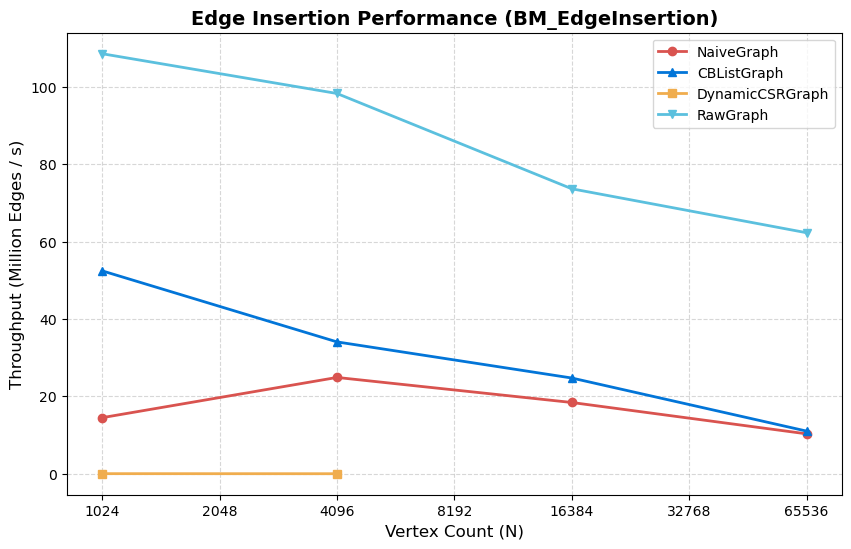

In [11]:
plt.figure(figsize=(10, 6))

for g_type, metrics in data["Insertion"].items():
    plt.plot(metrics["N"], metrics["tp"], marker=markers.get(g_type, 'o'), color=colors.get(g_type, 'black'), label=g_type, linewidth=2)

plt.xscale("log", base=2)
plt.title("Edge Insertion Performance (BM_EdgeInsertion)", fontsize=14, fontweight="bold")
plt.xlabel("Vertex Count (N)", fontsize=12)
plt.ylabel("Throughput (Million Edges / s)", fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.show()

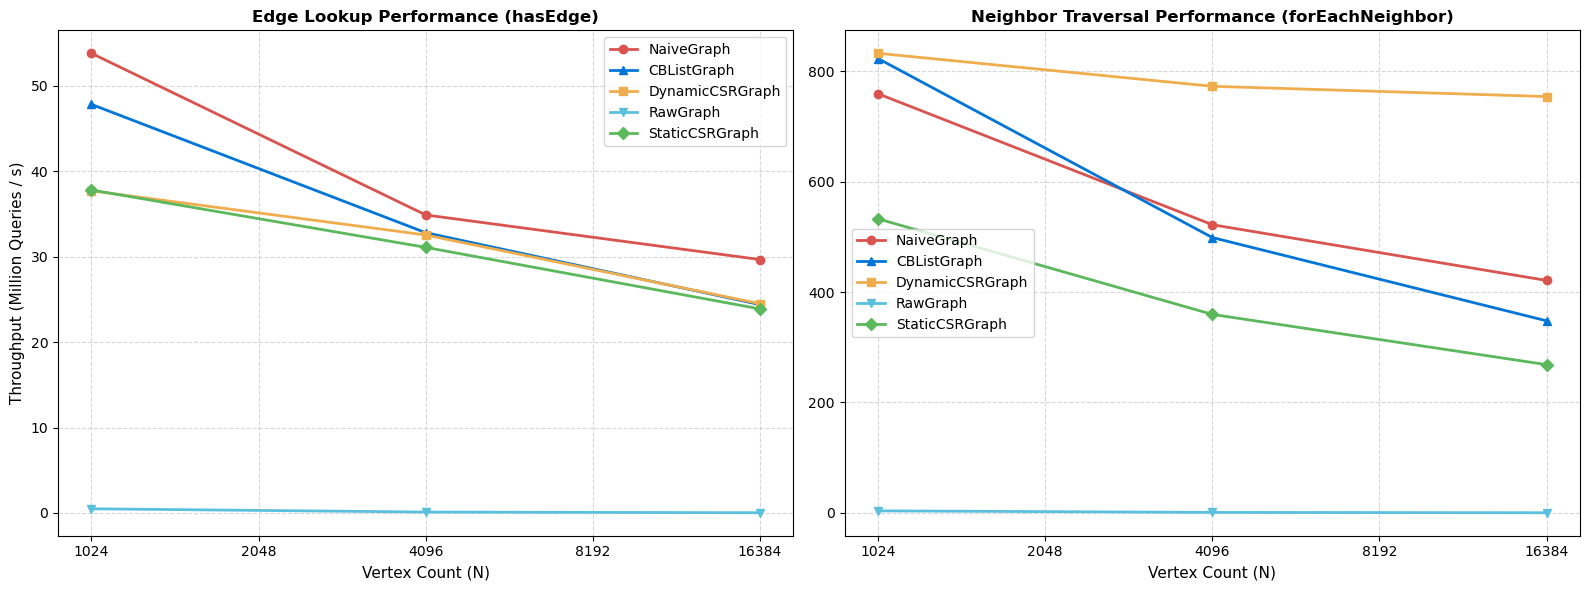

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Edge Lookup
for g_type, metrics in data["Lookup"].items():
    ax1.plot(metrics["N"], metrics["tp"], marker=markers.get(g_type, 'o'), color=colors.get(g_type, 'black'), label=g_type, linewidth=2)
ax1.set_xscale("log", base=2)
ax1.set_title("Edge Lookup Performance (hasEdge)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Vertex Count (N)", fontsize=11)
ax1.set_ylabel("Throughput (Million Queries / s)", fontsize=11)
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend()
ax1.xaxis.set_major_formatter(ScalarFormatter())

# Plot 2: Neighbor Traversal
for g_type, metrics in data["Traversal"].items():
    ax2.plot(metrics["N"], metrics["tp"], marker=markers.get(g_type, 'o'), color=colors.get(g_type, 'black'), label=g_type, linewidth=2)
ax2.set_xscale("log", base=2)
ax2.set_title("Neighbor Traversal Performance (forEachNeighbor)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Vertex Count (N)", fontsize=11)
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.legend()
ax2.xaxis.set_major_formatter(ScalarFormatter())

plt.tight_layout()
plt.show()

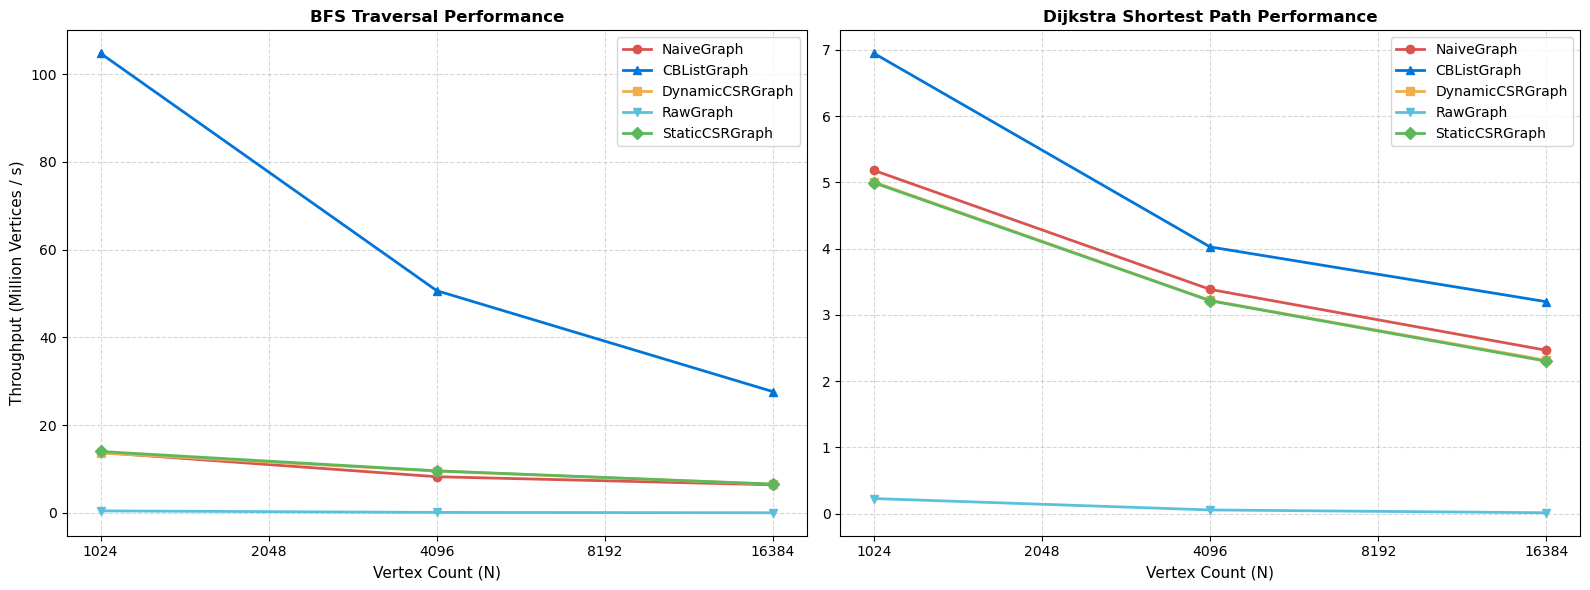

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: BFS
for g_type, metrics in data["BFS"].items():
    ax1.plot(metrics["N"], metrics["tp"], marker=markers.get(g_type, 'o'), color=colors.get(g_type, 'black'), label=g_type, linewidth=2)
ax1.set_xscale("log", base=2)
ax1.set_title("BFS Traversal Performance", fontsize=12, fontweight="bold")
ax1.set_xlabel("Vertex Count (N)", fontsize=11)
ax1.set_ylabel("Throughput (Million Vertices / s)", fontsize=11)
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend()
ax1.xaxis.set_major_formatter(ScalarFormatter())

# Plot 2: Dijkstra
for g_type, metrics in data["Dijkstra"].items():
    ax2.plot(metrics["N"], metrics["tp"], marker=markers.get(g_type, 'o'), color=colors.get(g_type, 'black'), label=g_type, linewidth=2)
ax2.set_xscale("log", base=2)
ax2.set_title("Dijkstra Shortest Path Performance", fontsize=12, fontweight="bold")
ax2.set_xlabel("Vertex Count (N)", fontsize=11)
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.legend()
ax2.xaxis.set_major_formatter(ScalarFormatter())

plt.tight_layout()
plt.show()

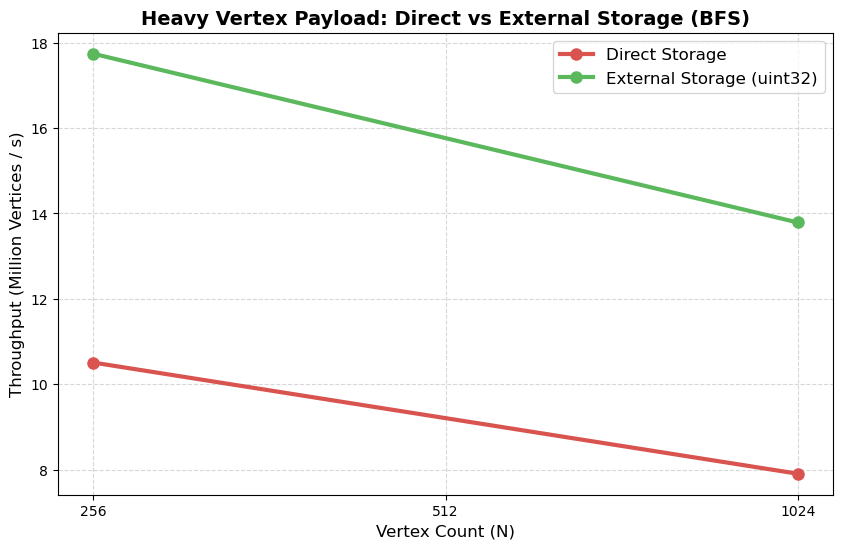

In [14]:
plt.figure(figsize=(10, 6))

# Specific colors for comparing architectures rather than graph types
bc_colors = {'Direct Storage': '#d9534f', 'External Storage (uint32)': '#5cb85c'}

for g_type, metrics in data["BigClass"].items():
    plt.plot(metrics["N"], metrics["tp"], marker='o', color=bc_colors[g_type], label=g_type, linewidth=3, markersize=8)

plt.xscale("log", base=2)
plt.title("Heavy Vertex Payload: Direct vs External Storage (BFS)", fontsize=14, fontweight="bold")
plt.xlabel("Vertex Count (N)", fontsize=12)
plt.ylabel("Throughput (Million Vertices / s)", fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.show()

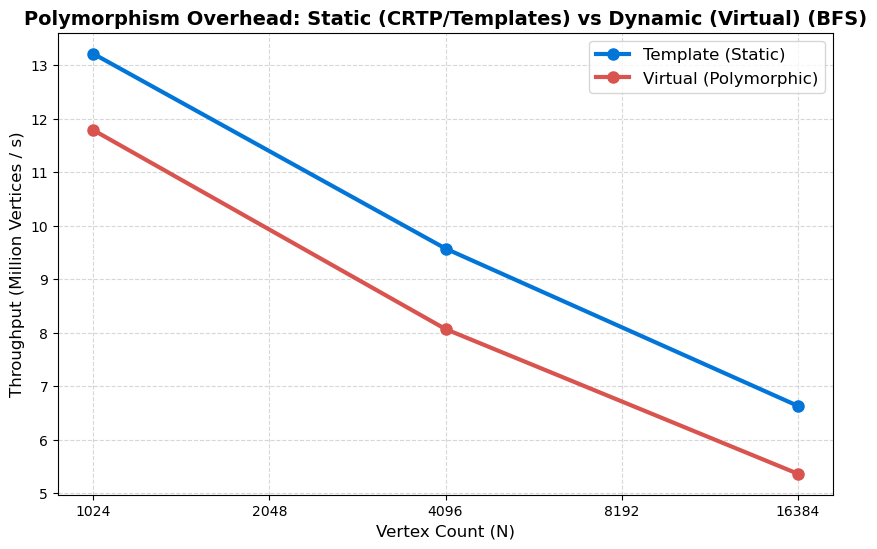

In [17]:
plt.figure(figsize=(10, 6))

poly_colors = {
    'Template (Static)': '#0275d8',
    'Virtual (Polymorphic)': '#d9534f'
}

for poly_type, metrics in data["Polymorphism"].items():
    plt.plot(metrics["N"], metrics["tp"], marker='o', color=poly_colors[poly_type], label=poly_type, linewidth=3, markersize=8)

plt.xscale("log", base=2)
plt.title("Polymorphism Overhead: Static (CRTP/Templates) vs Dynamic (Virtual) (BFS)", fontsize=14, fontweight="bold")
plt.xlabel("Vertex Count (N)", fontsize=12)
plt.ylabel("Throughput (Million Vertices / s)", fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.show()